In [1]:
#looking at sn thats available in blast and our data:

import numpy as np
import pandas as pd
import  matplotlib.pyplot as plt
import math
from urllib.request import urlopen
import json
import itertools

In [2]:
ogData = pd.read_csv('~/Desktop/AggieNova-UVHosts/Kcorrections/FinalPhotUV.dat', sep  ='\s+')
ogData.set_index('sn', inplace=True)

for sn in ogData.index:
    if "SNF" in sn:  # Check within each string
        print(sn)

SNF20080514002


In [3]:
#defining funtion to check existence of each sn 

def snMatch():
    missingSN =[]
    existingSN =[]
    
    for name in ogData.index:
        try:
            response = urlopen(f"https://blast.scimma.org/api/transient/get/{name}?format=json")
            if response.status == 200:
                    existingSN.append(name)
                        
        except Exception as e:
            missingSN.append(name)
            
    return existingSN, missingSN

existingSN, missingSN = snMatch()
missingSN

['SNF20080514002']

In [4]:
#length 1 - which is just wrong name
snfile = 'missingSN.txt'
with open(snfile, 'w') as snfile:
    for item in missingSN:
        snfile.write(str(item) + '\n')
snfile.close()

In [5]:
#defining relevant functions
def findErr(bot, med, top):
    topErr = abs(float(top) - float(med))
    botErr = abs(float(bot) - float(med))
    Err = (topErr+botErr)/2
    return Err

def safe_get(data, key, default=None):
    return data.get(key, default)

In [6]:
existingData ={}

properties = ['log_mass', 'log_ssfr', 'log_age', 'logzsol', 'dust2', 'dust_index']


    
for name in existingSN:
    response = urlopen(f"https://blast.scimma.org/api/transient/get/{name}?format=json")
    data = json.loads(response.read())

    for prop in properties:
        prop_16 = safe_get(data, f"global_aperture_host_{prop}_16")
        prop_50 = safe_get(data, f"global_aperture_host_{prop}_50")
        prop_84 = safe_get(data, f"global_aperture_host_{prop}_84")

        err = findErr(prop_16, prop_50, prop_84) if prop_16 and prop_84 else None

#adding relevant data to dictionary
#existingData[name].append(name)
        existingData.setdefault(name, {})[prop] = {
            'median': prop_50,
            'err': err
        }

In [7]:
existingData['SN2011B']['log_ssfr']["err"]

0.5860364810311074

In [8]:
#some websites the server is weird, doesnt show galaxy data
#weirdSN = ['PS1-14xw','ASASSN-14lw', 'ASASSN-15od', 'ASASSN-15aj','ASASSN-15hx', 'SN2008Q']
weirdSN=[]

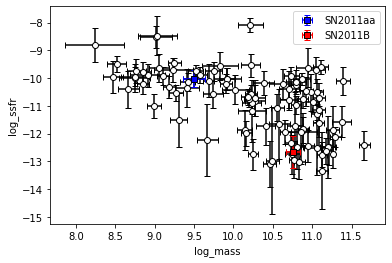

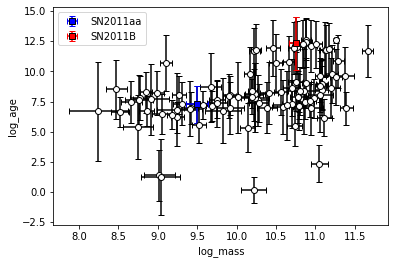

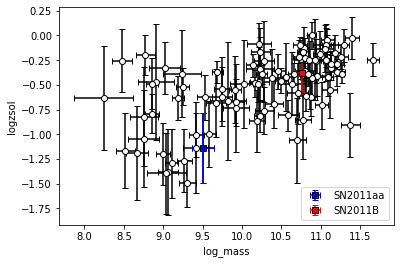

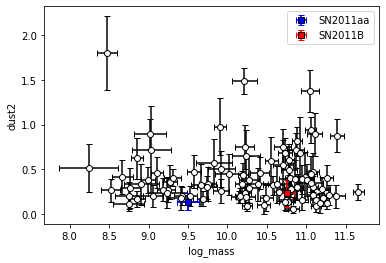

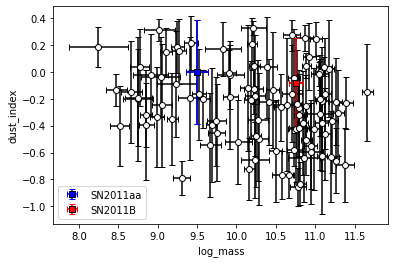

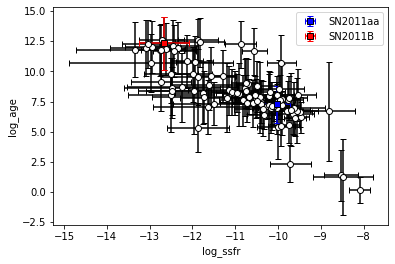

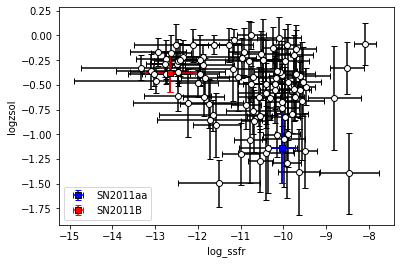

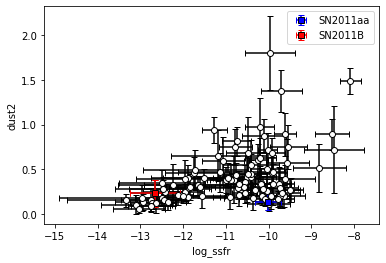

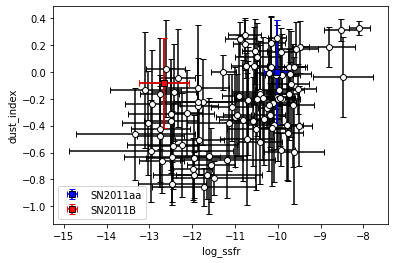

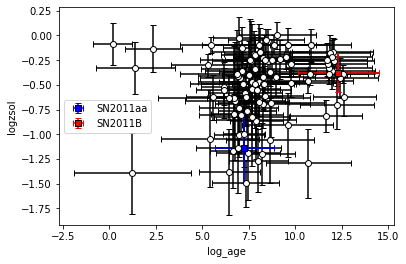

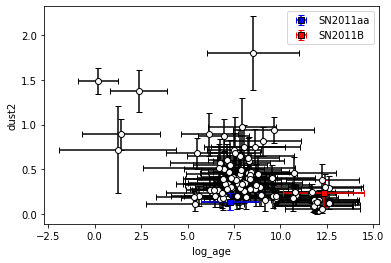

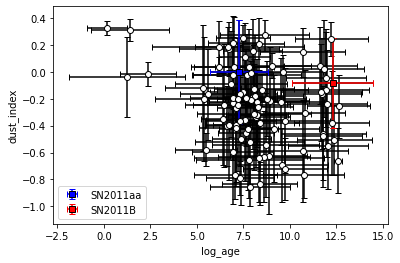

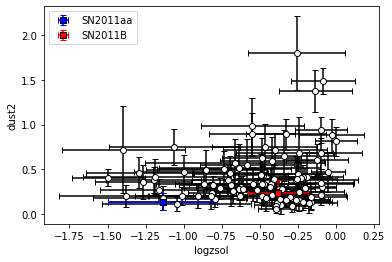

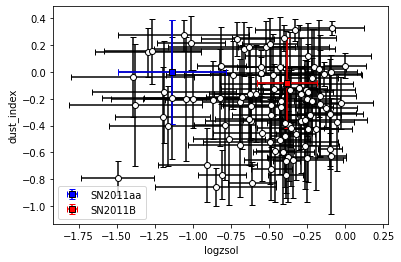

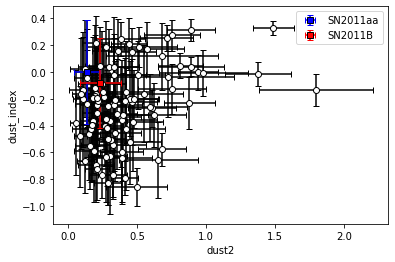

In [9]:
for prop1, prop2 in itertools.combinations(properties, 2):
    plt.figure()

    for sn in existingData.values():
        x = sn[prop1]["median"]
        y = sn[prop2]["median"]
        xe = sn[prop1]["err"]
        ye = sn[prop2]["err"]

        # skip if x or y missing
        if x is None or y is None or not np.isfinite(x) or not np.isfinite(y):
            continue

        # only pass errorbars if they are finite; otherwise use None
        xerr = xe if (xe is not None and np.isfinite(xe)) else None
        yerr = ye if (ye is not None and np.isfinite(ye)) else None

        plt.errorbar(
            x, y,
            xerr=xerr, yerr=yerr,
            fmt='o', ecolor='k', mfc='white', mec='k', capsize=3
        )

    # highlight red/blue points
    bluest = 'SN2011aa'
    reddest = 'SN2011B'
    for name, color, label in [(bluest, 'blue', 'SN2011aa'),
                               (reddest, 'red',  'SN2011B')]:
        xb = existingData[name][prop1]["median"]
        yb = existingData[name][prop2]["median"]
        xbe = existingData[name][prop1]["err"]
        ybe = existingData[name][prop2]["err"]
        xerrb = xbe if (xbe is not None and np.isfinite(xbe)) else None
        yerrb = ybe if (ybe is not None and np.isfinite(ybe)) else None

        if xb is not None and yb is not None and np.isfinite(xb) and np.isfinite(yb):
            plt.errorbar(xb, yb, xerr=xerrb, yerr=yerrb,
                         fmt='s', ecolor=color, mfc=color, mec='k', capsize=3, label=label)

    plt.xlabel(prop1)
    plt.ylabel(prop2)
    plt.legend()
    plt.savefig(f'prop_plots/{prop1}vs{prop2}')
    plt.show()


# Prop vs Color Plots

In [14]:
#plotting the various galaxy parameters on the x axis 
#with different supernova colors and galaxy colors on the y axis.
file = '~/Desktop/AggieNova-UVHosts/Kcorrections/FinalPhotUV.dat'
df= pd.read_csv(file, sep='\s+')

Kfile = '~/Desktop/AggieNova-UVHosts/Kcorrections/KcorrectedFinalPhotUV.csv'
K_df= pd.read_csv(Kfile, sep=',')

SNfile = '~/Desktop/AggieNova-UVHosts/Photometry/outputmags_color.dat'
SN_df= pd.read_csv(SNfile, sep='\s+')


#for og df
UVW2 = df.loc[:,'UVW2']
UVW1 = df.loc[:,'UVW1']
UVM2 = df.loc[:, 'UVM2']
B = df.loc[:, 'B']
V = df.loc[:,'V']

errUVW2 = df.loc[:,'errUVW2']
errUVW1 = df.loc[:,'errUVW1']
errUVM2 = df.loc[:, 'errUVM2']
errB = df.loc[:, 'errB']
errV = df.loc[:,'errV']


#for Kdf
K_UVW2 = K_df.loc[:,'K_UVW2']
K_UVW1 = K_df.loc[:,'K_UVW1']
K_UVM2 = K_df.loc[:, 'K_UVM2']
K_B = K_df.loc[:, 'K_B']
K_V = K_df.loc[:,'K_V']

Kerr_UVW2 = K_df.loc[:,'Kerr_UVW2']
Kerr_UVW1 = K_df.loc[:,'Kerr_UVW1']
Kerr_UVM2 = K_df.loc[:, 'Kerr_UVM2']
Kerr_B = K_df.loc[:, 'Kerr_B']
Kerr_V = K_df.loc[:,'Kerr_V']

#for SNdf
SN_UVW2 = SN_df.loc[:,'SN_UVW2']
SN_UVW1 = SN_df.loc[:,'SN_UVW1']
SN_UVM2 = SN_df.loc[:, 'SN_UVM2']
SN_B = SN_df.loc[:, 'SN_B']
SN_V = SN_df.loc[:,'SN_V']

#get the shared SN names
common_sn = np.intersect1d(K_df['sn'], SN_df['sn'], list(existingData.keys()))

#only include those SN
K_matched = K_df[K_df['sn'].isin(common_sn)].reset_index(drop=True)
SN_matched = SN_df[SN_df['sn'].isin(common_sn)].reset_index(drop=True)
existingData_matched = {sn: existingData[sn] for sn in common_sn}

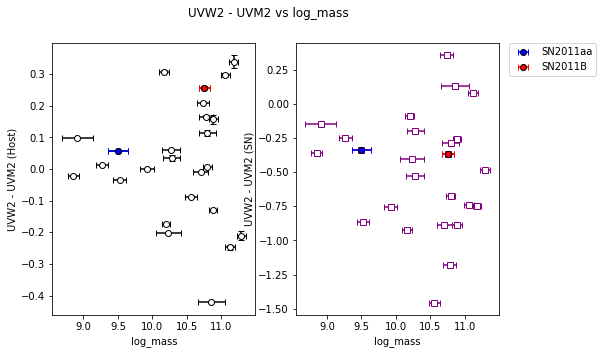

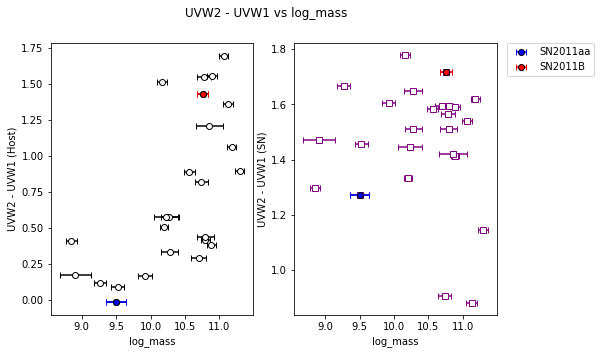

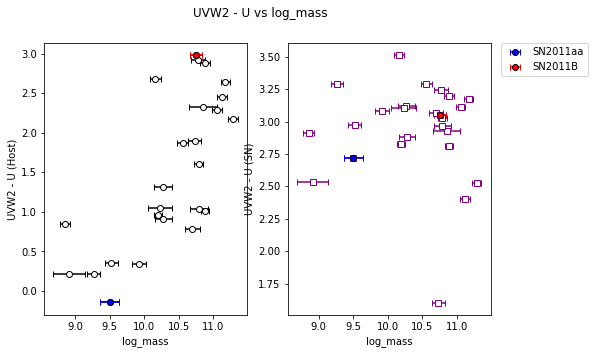

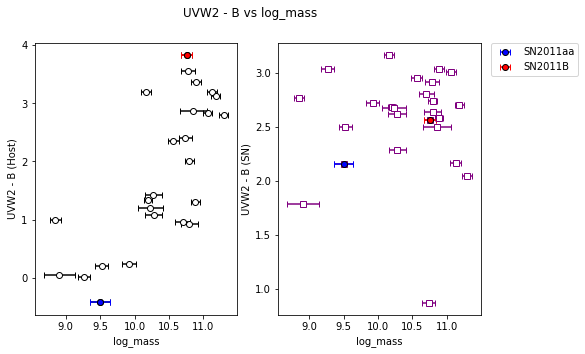

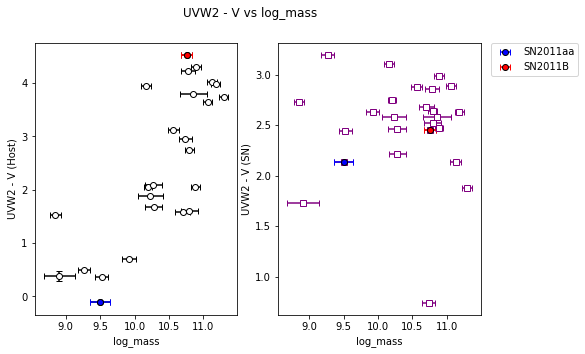

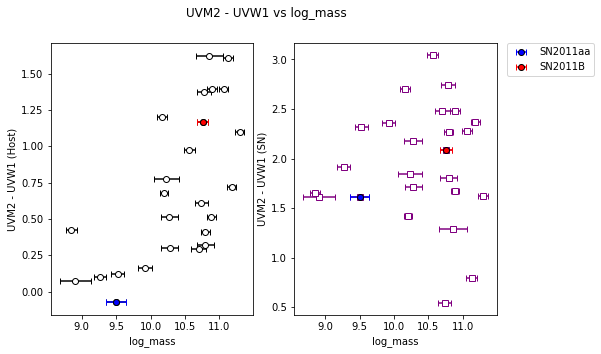

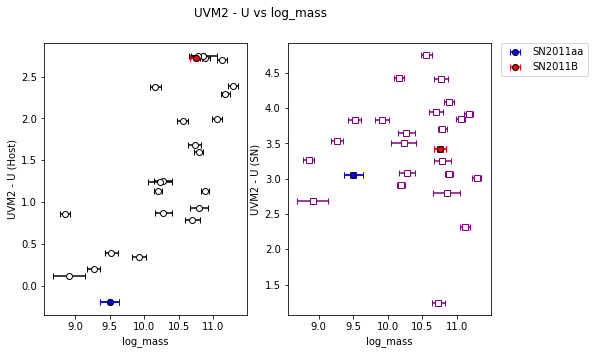

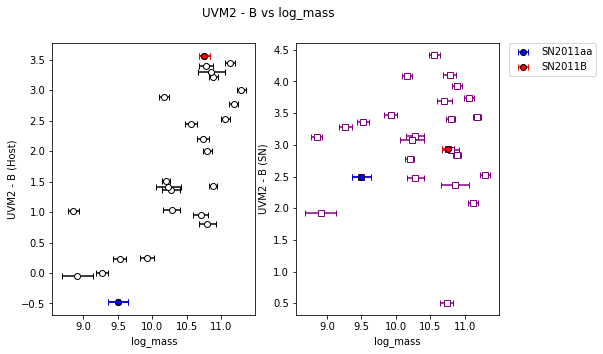

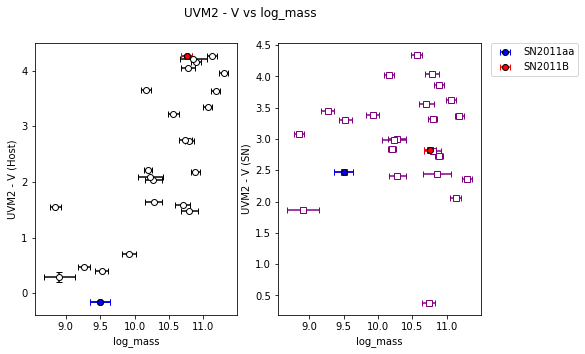

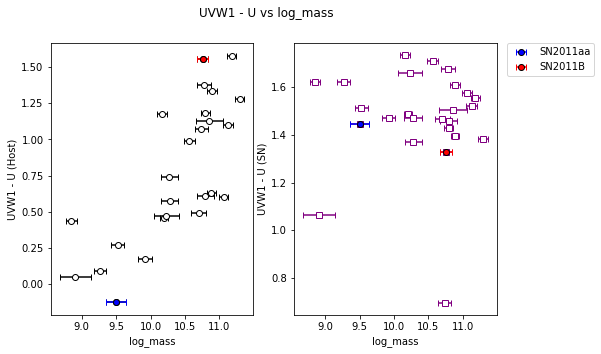

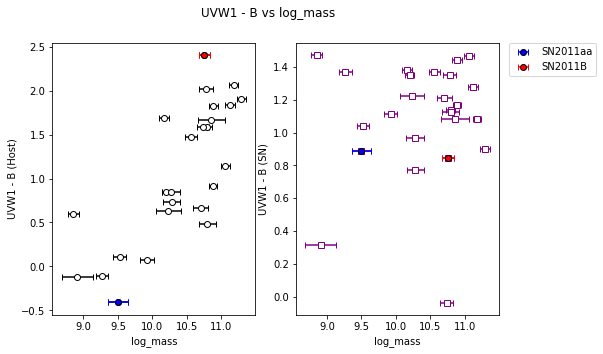

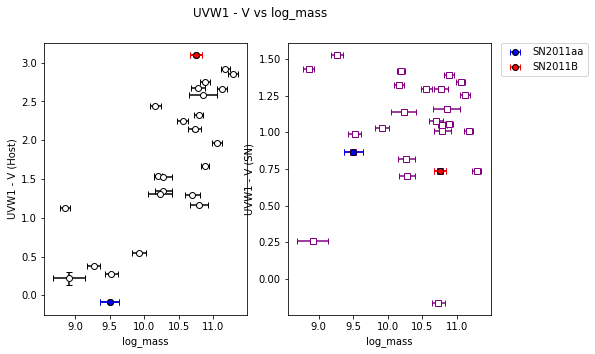

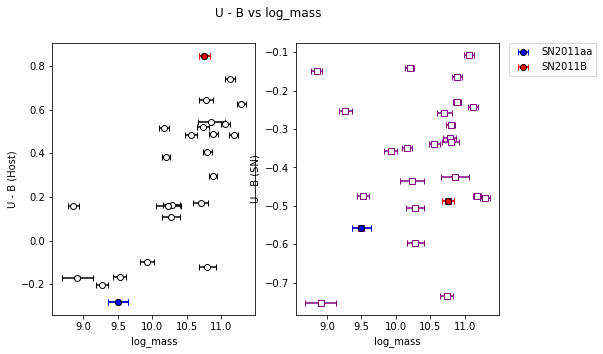

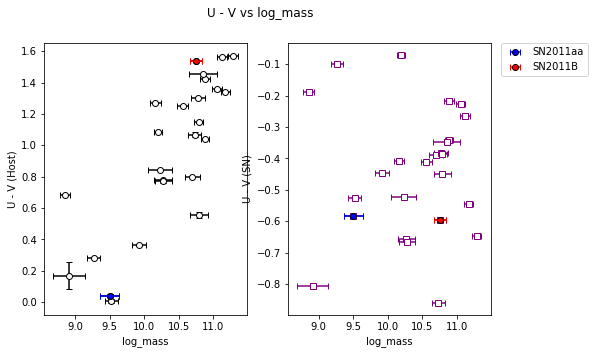

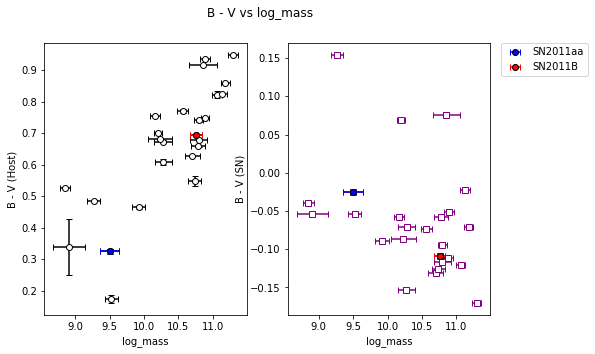

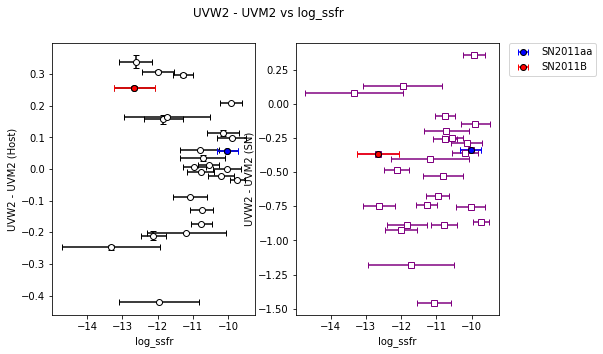

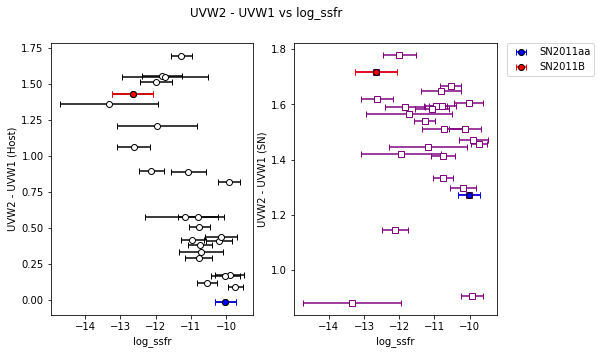

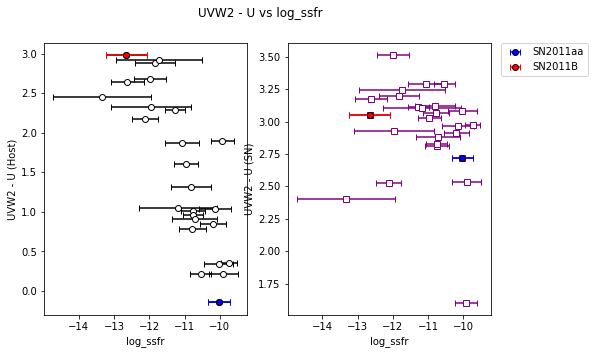

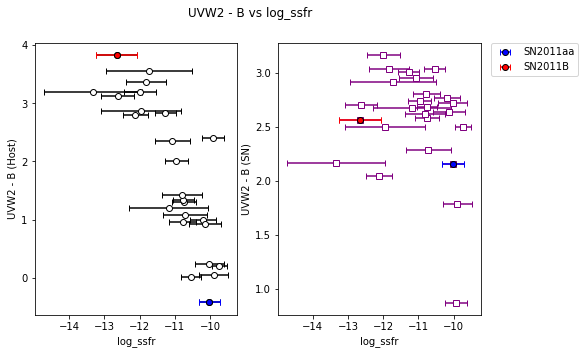

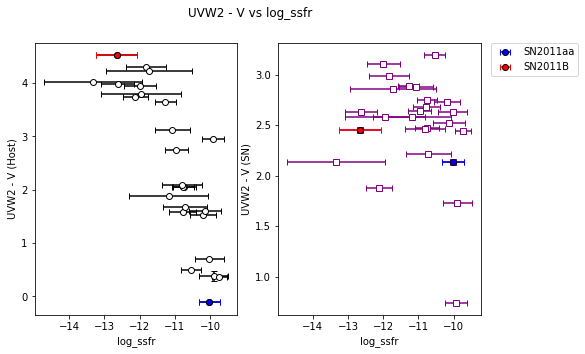

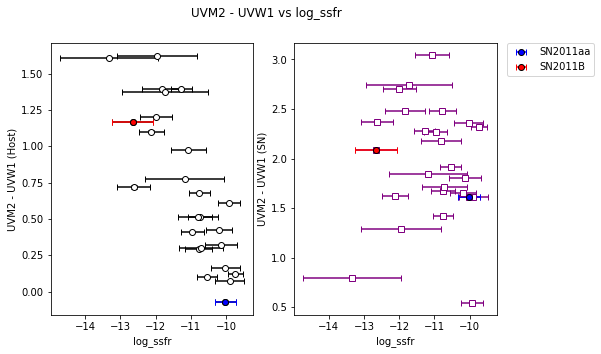

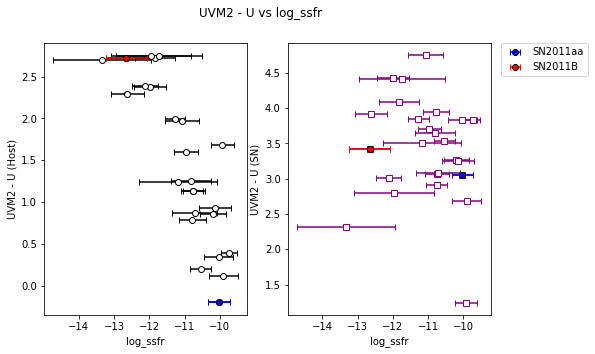

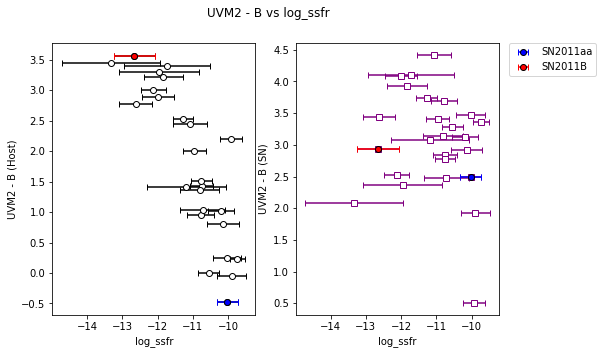

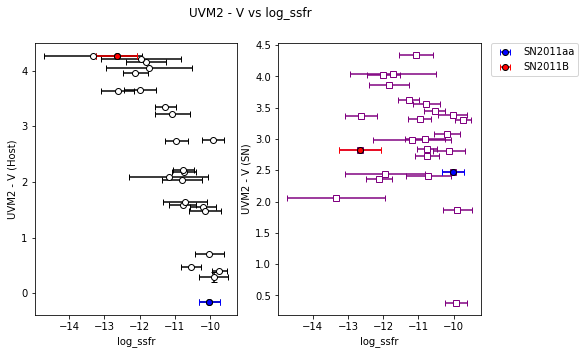

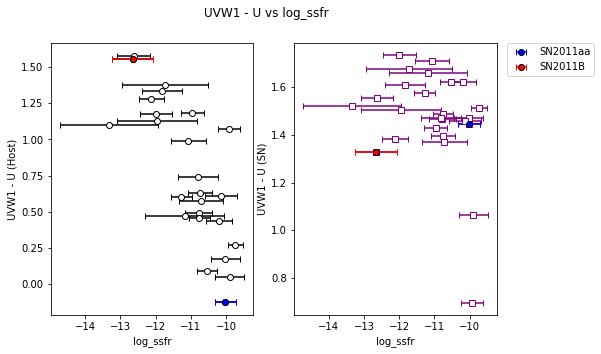

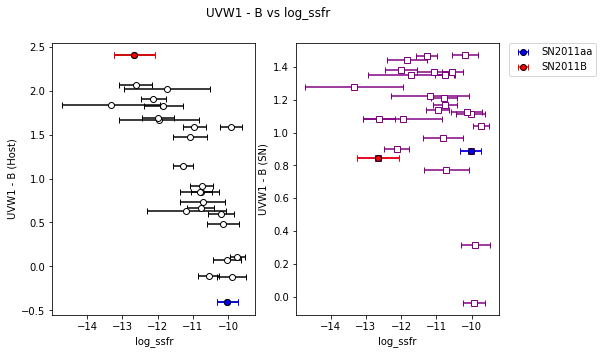

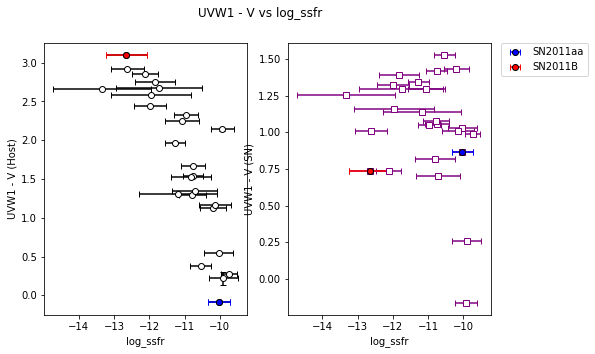

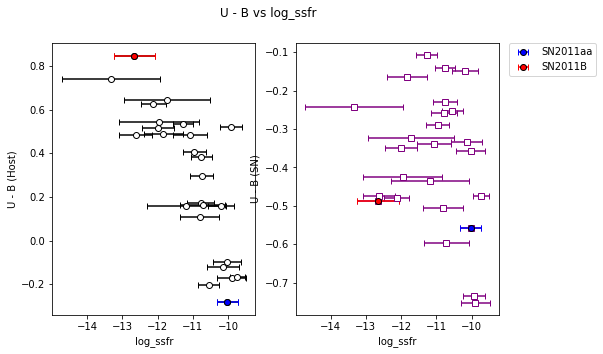

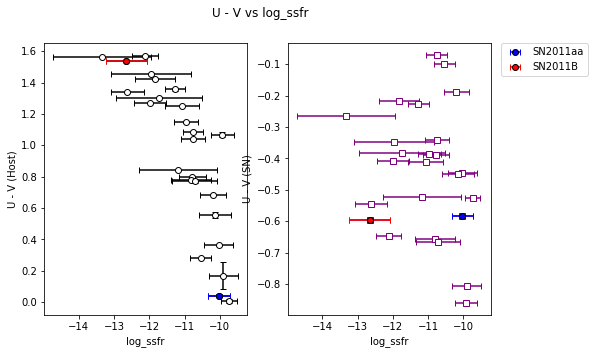

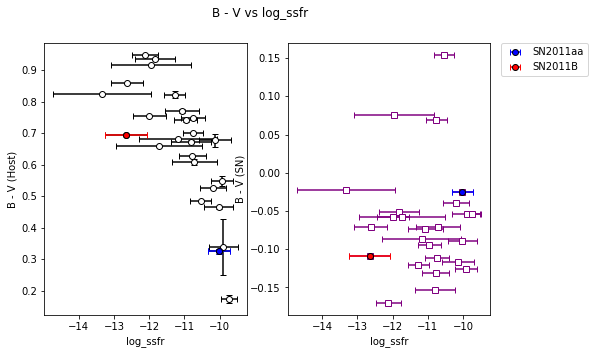

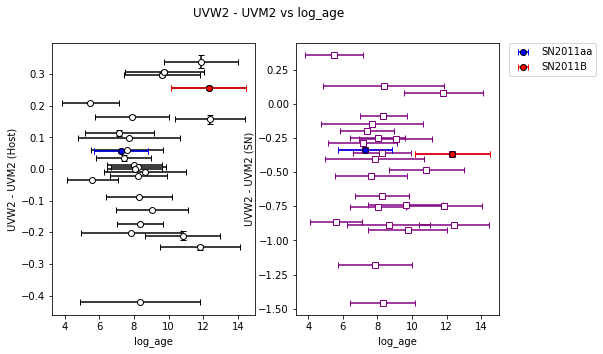

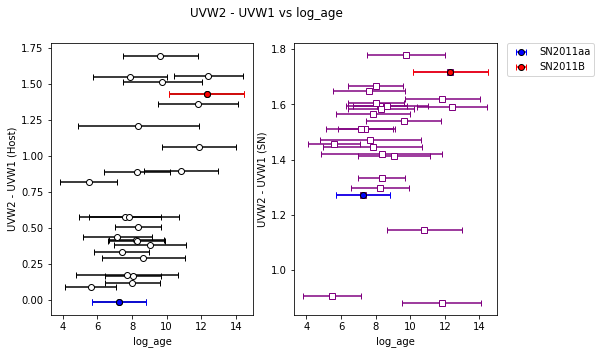

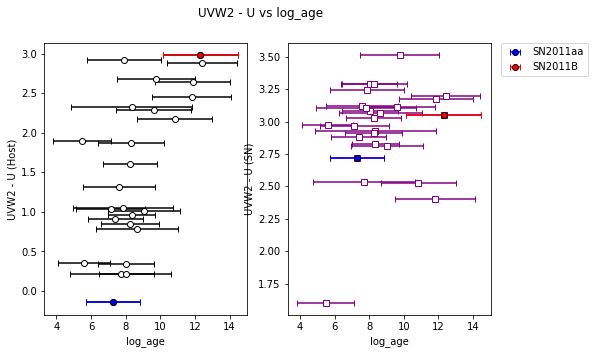

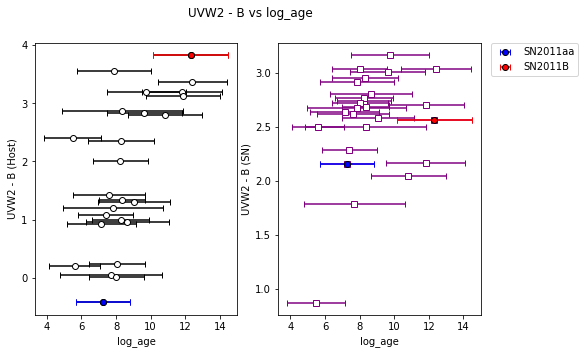

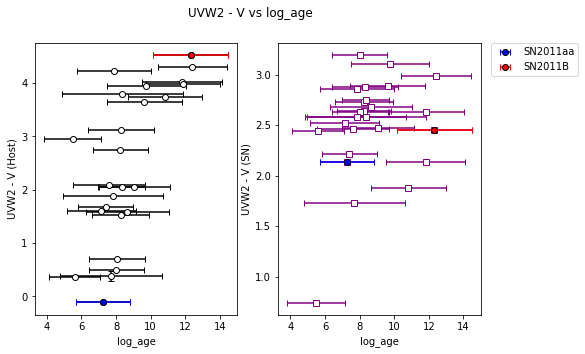

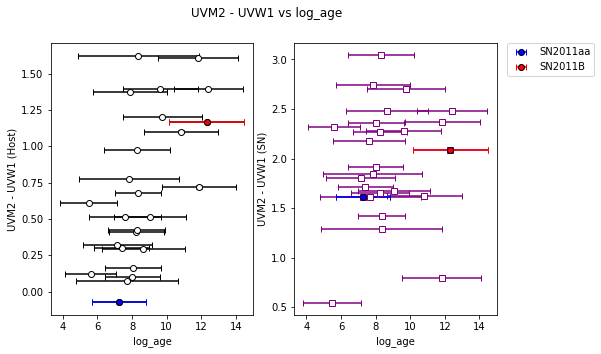

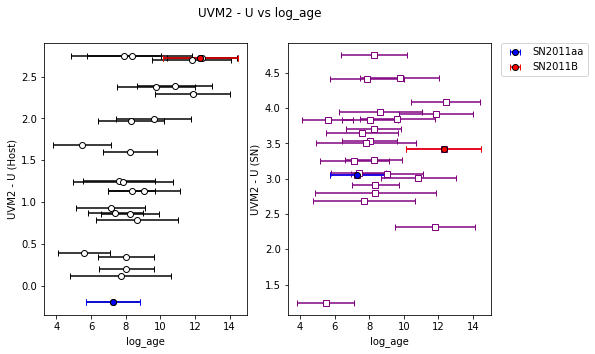

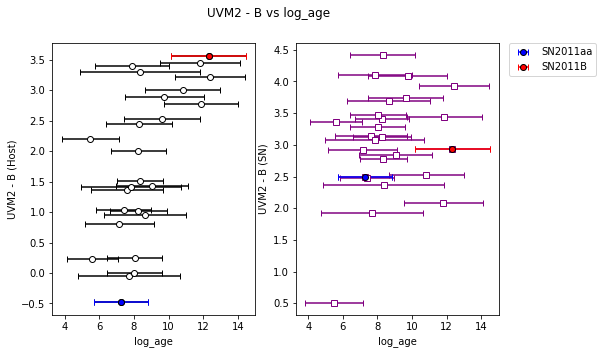

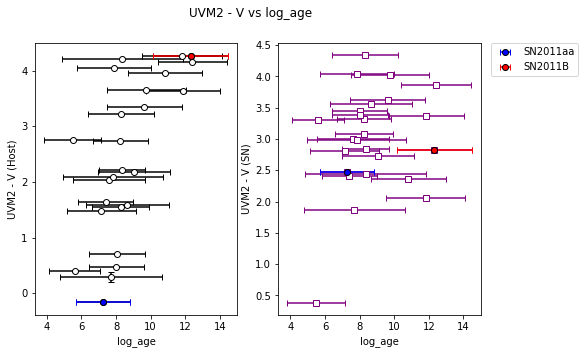

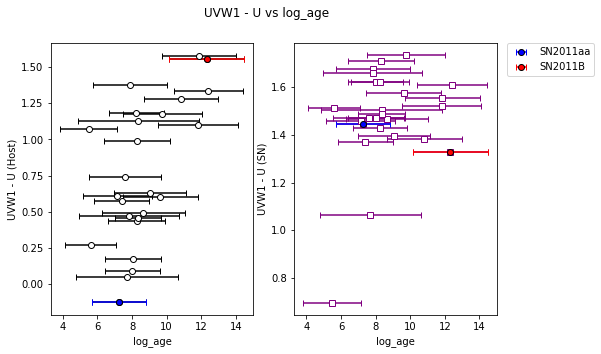

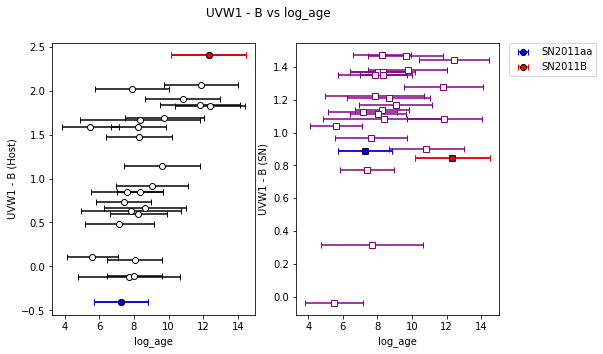

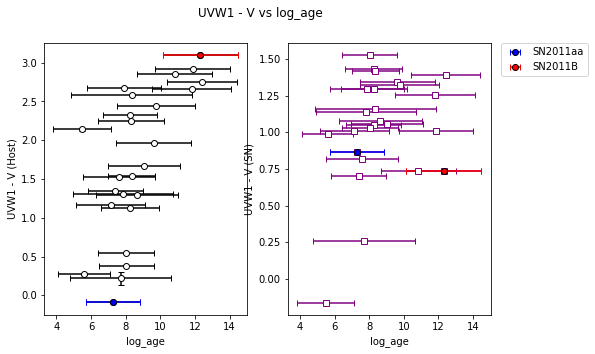

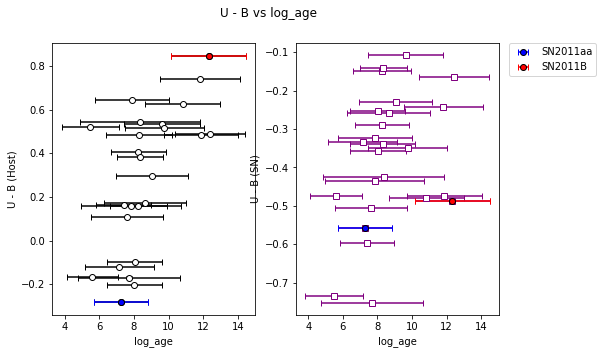

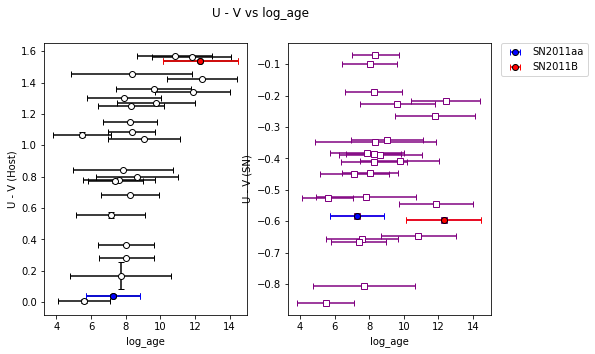

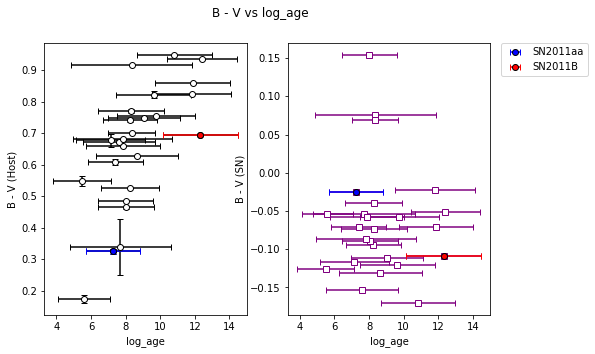

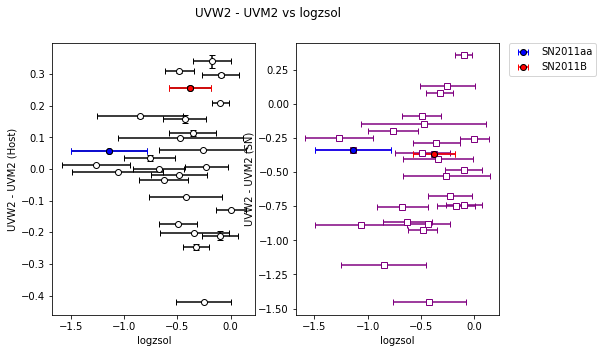

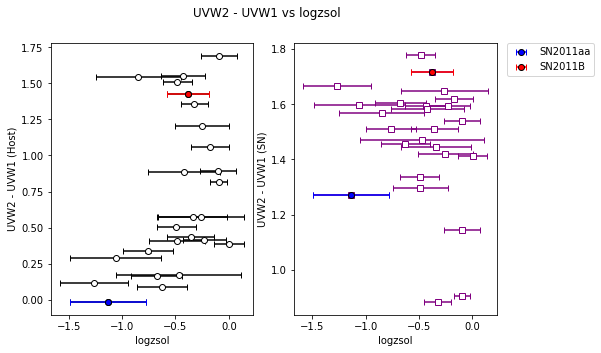

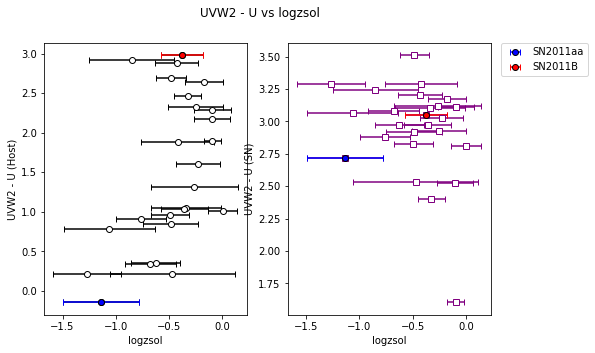

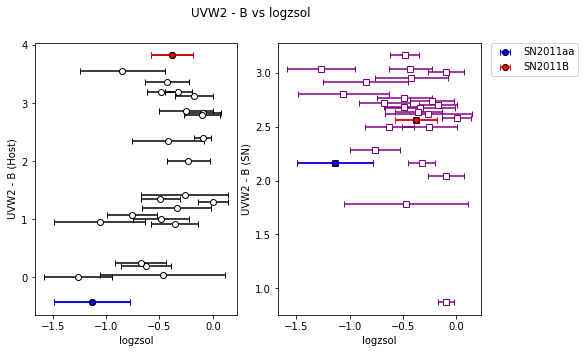

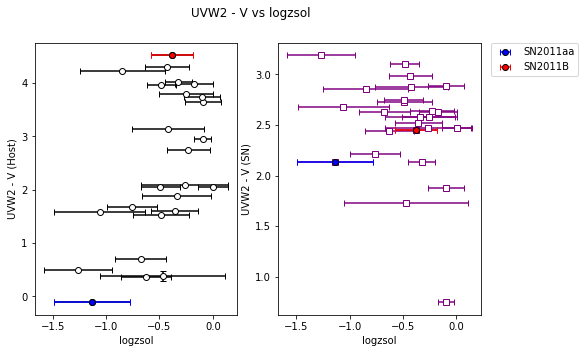

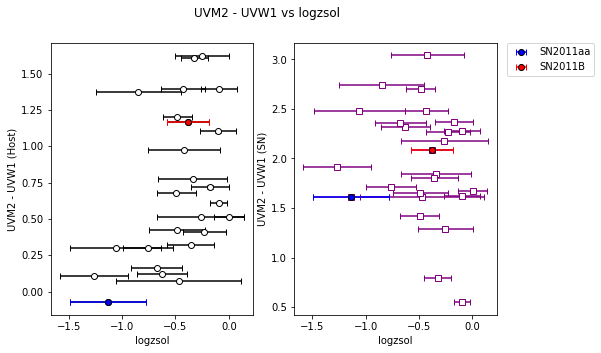

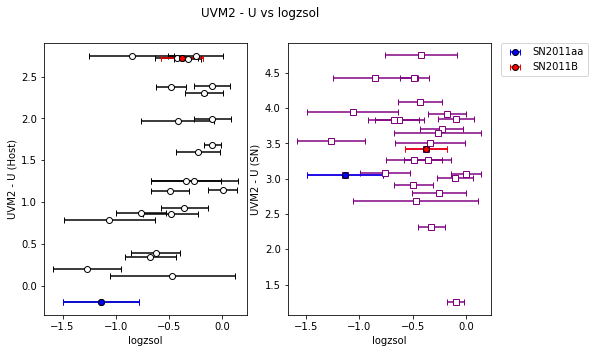

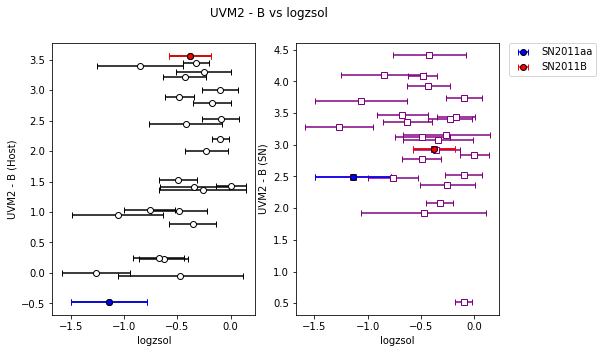

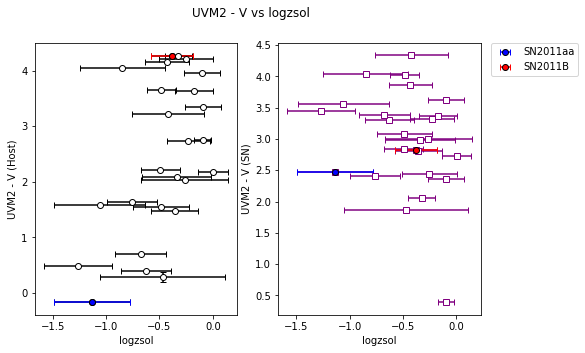

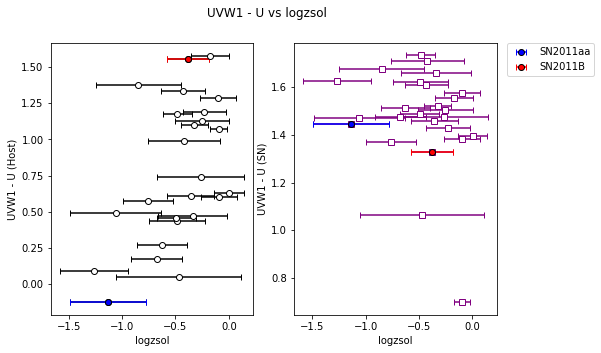

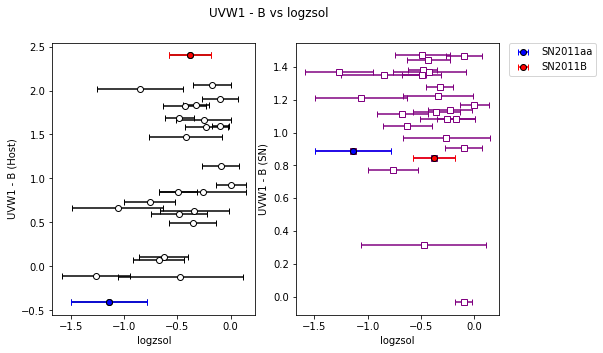

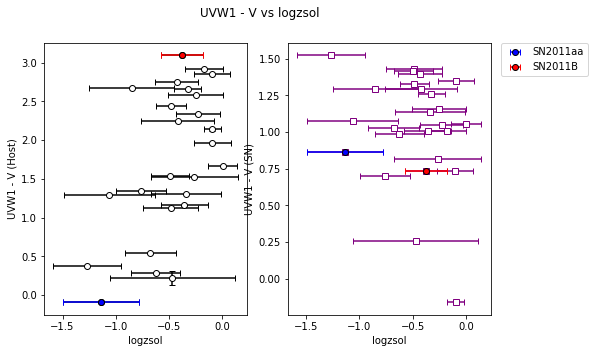

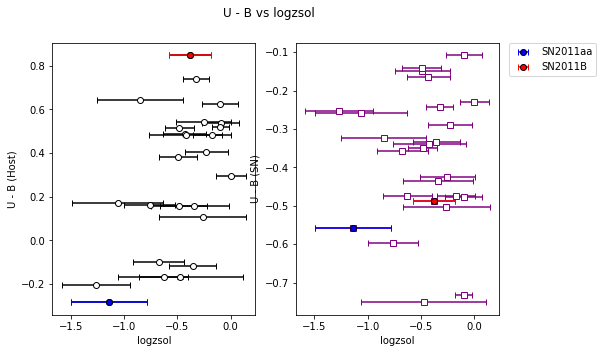

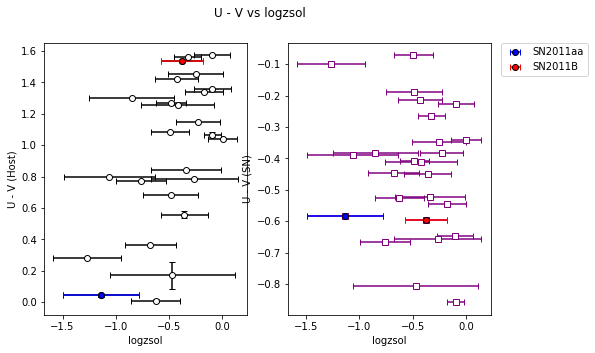

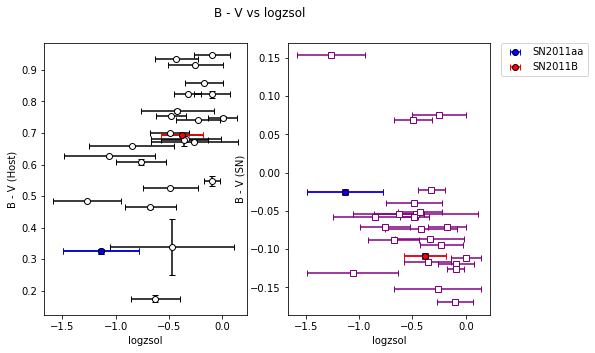

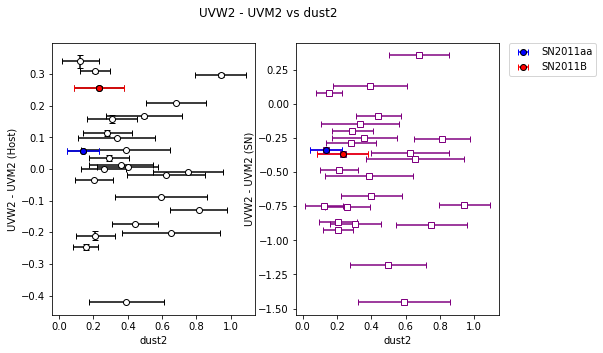

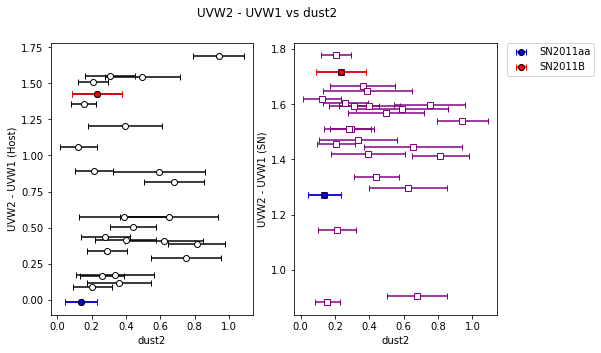

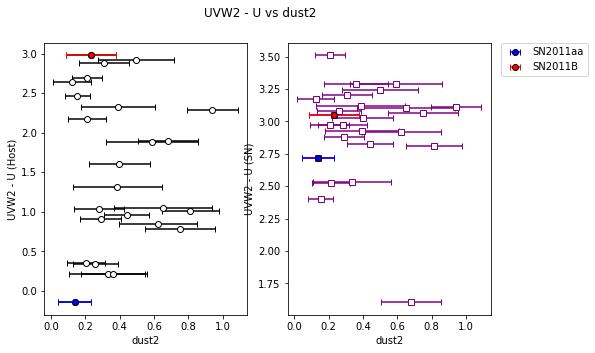

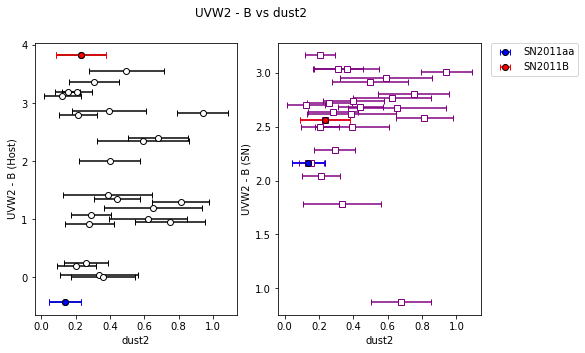

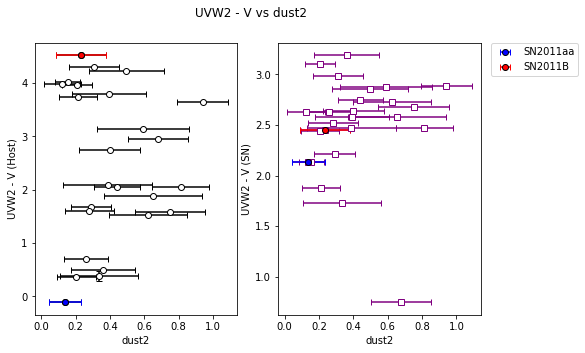

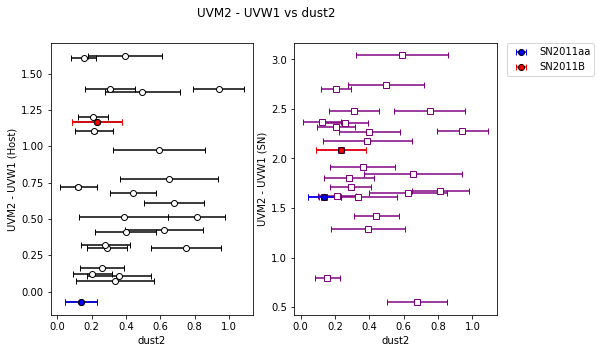

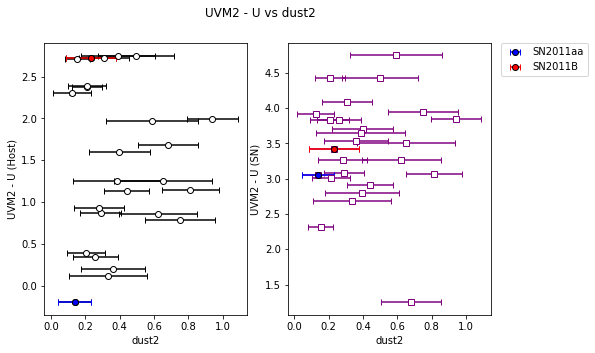

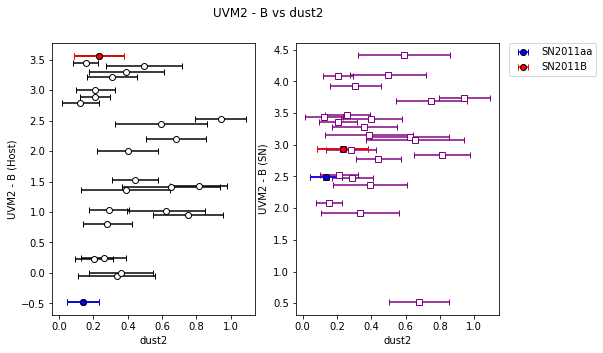

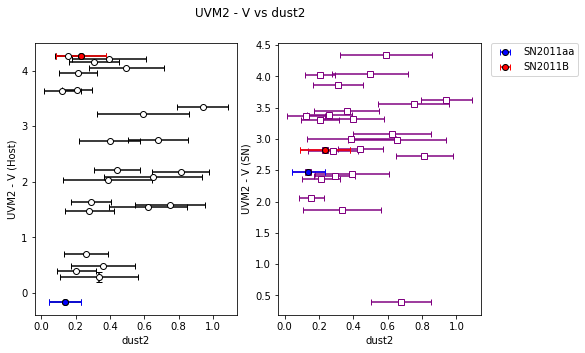

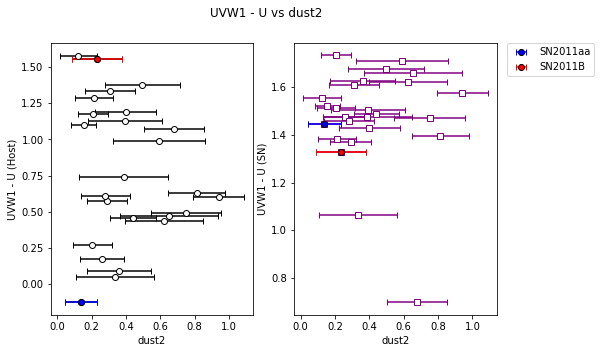

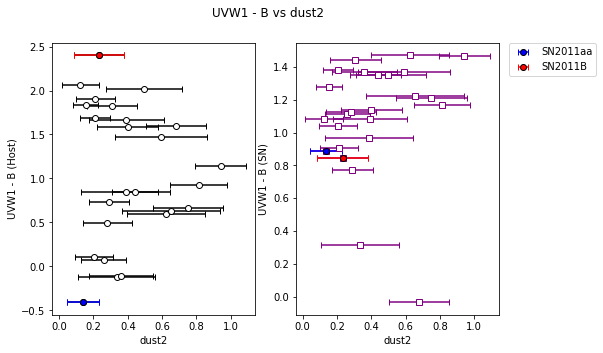

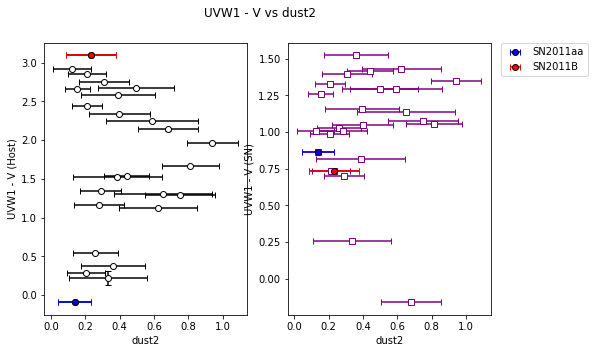

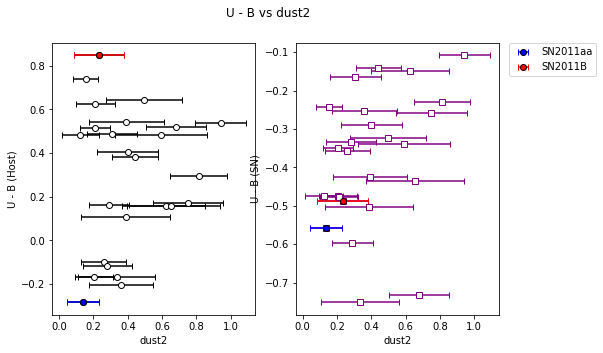

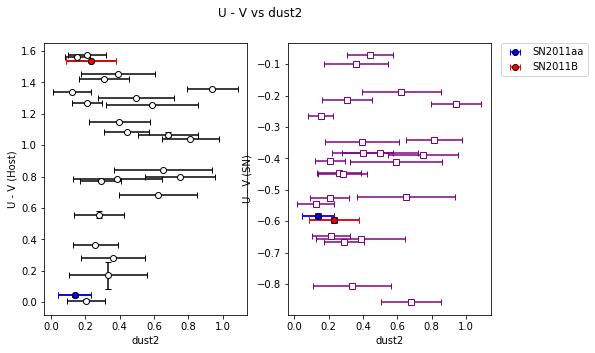

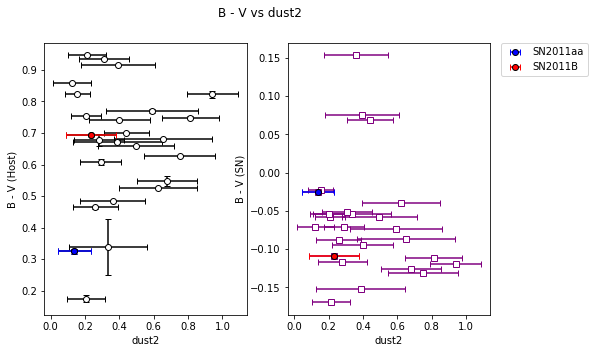

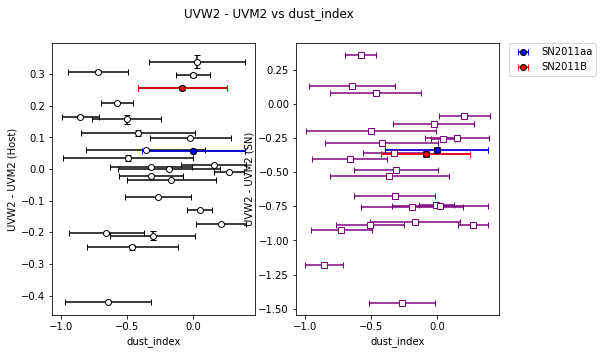

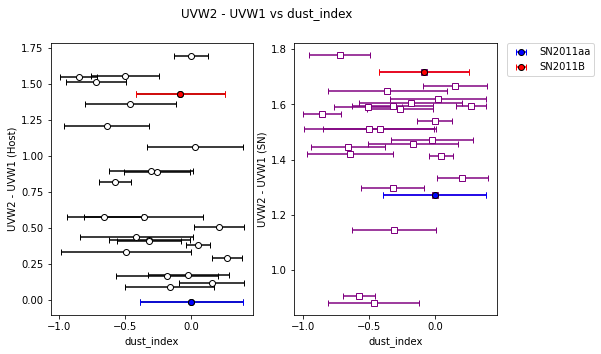

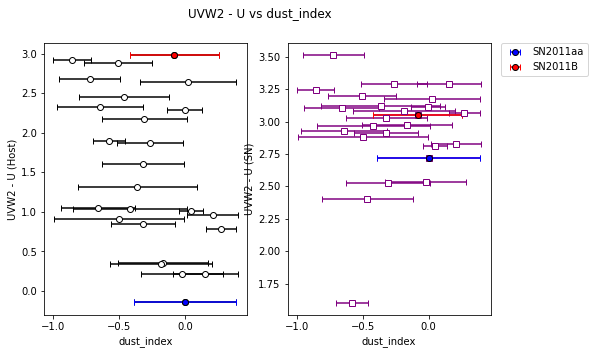

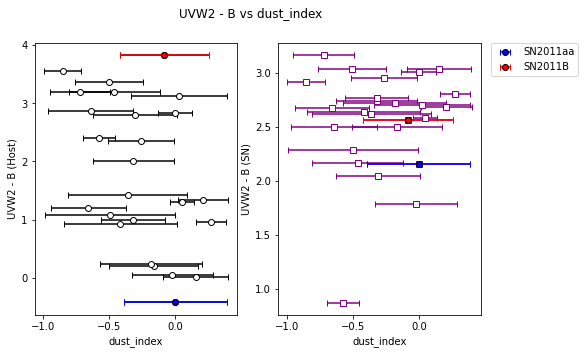

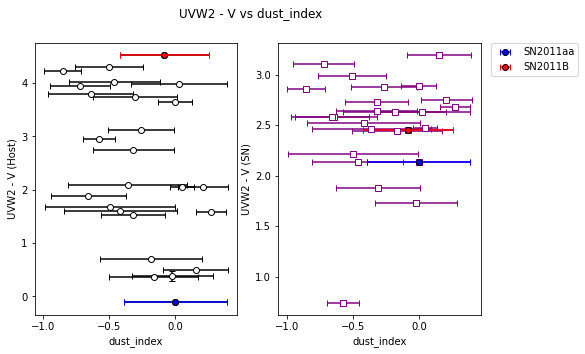

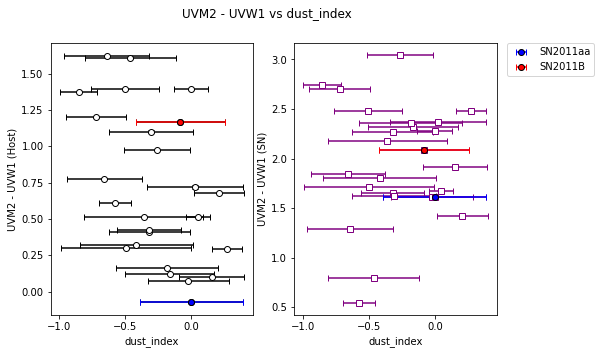

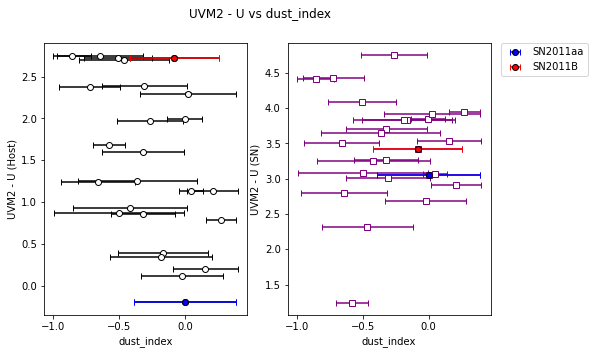

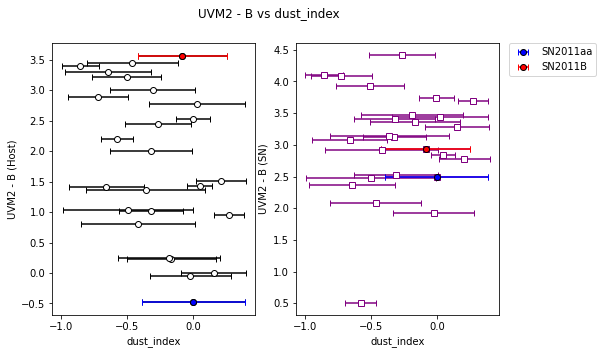

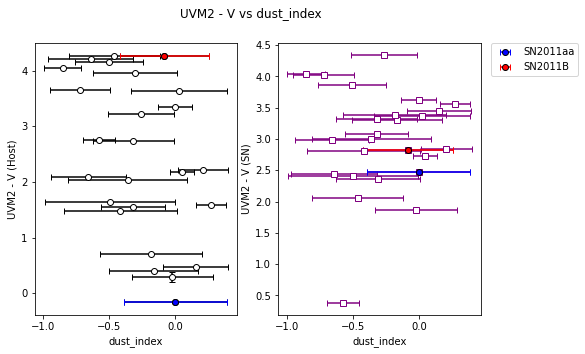

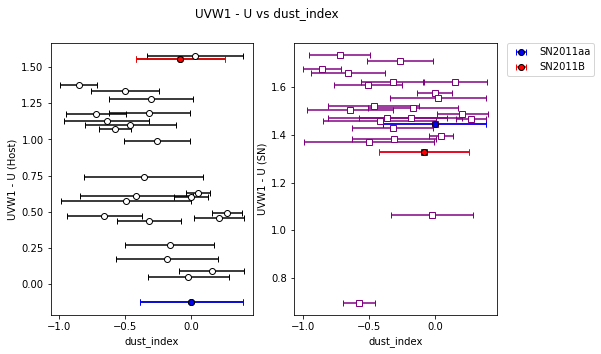

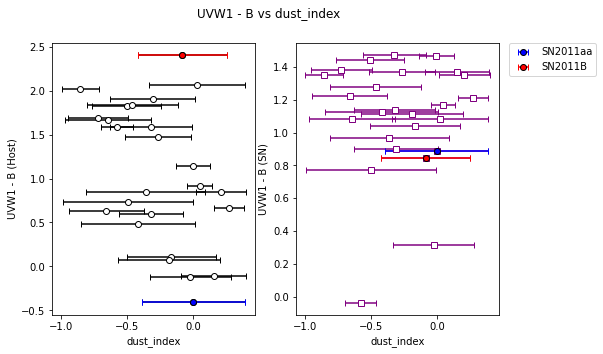

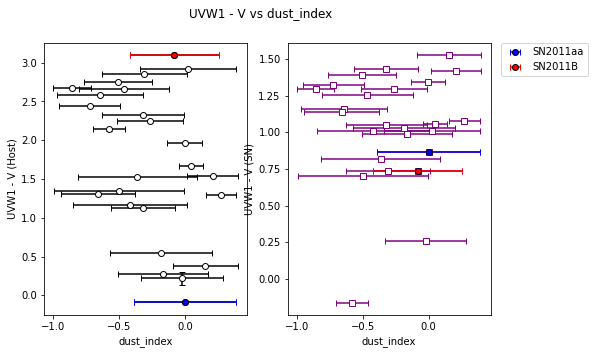

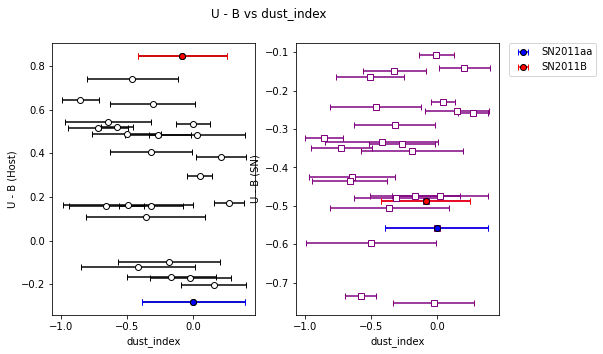

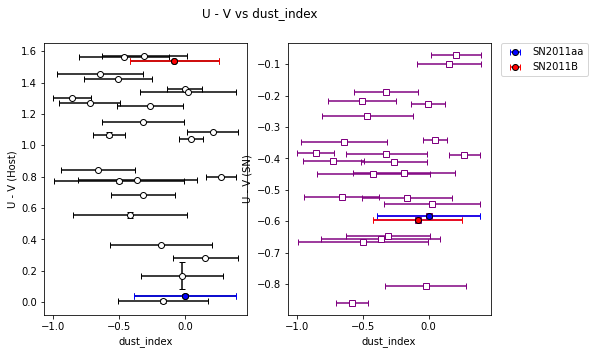

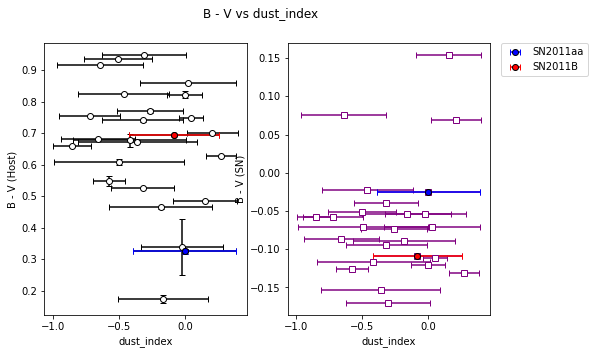

In [15]:
properties = ['log_mass', 'log_ssfr', 'log_age', 'logzsol', 'dust2', 'dust_index']
filters = ['UVW2', 'UVM2', 'UVW1', 'U', 'B', 'V']

for prop in properties:
    for fil1, fil2 in itertools.combinations(filters, 2):

        x_vals = []
        x_errs = []
        y1_vals = []
        y1_errs = []
        y2_vals = []
        sn_names = []

        for sn in existingData_matched.keys():
            try:
                x = existingData_matched[sn][prop]["median"]
                xe = existingData_matched[sn][prop]["err"]
                if x is None or not np.isfinite(x): continue
                xerr = xe if (xe is not None and np.isfinite(xe)) else None

                i = K_matched[K_matched['sn'] == sn].index[0]

                y1 = K_matched.loc[i, f'K_{fil1}'] - K_matched.loc[i, f'K_{fil2}']
                y1e = abs(K_matched.loc[i, f'Kerr_{fil1}'] - K_matched.loc[i, f'Kerr_{fil2}'])
                y2 = SN_matched.loc[i, f'SN_{fil1}'] - SN_matched.loc[i, f'SN_{fil2}']

                if not np.isfinite(y1) or not np.isfinite(y2): continue

                x_vals.append(x)
                x_errs.append(xerr)
                y1_vals.append(y1)
                y1_errs.append(y1e)
                y2_vals.append(y2)
                sn_names.append(sn)

            except:
                continue

        # 2 side by side plots
        fig, axs = plt.subplots(1, 2, figsize=(8, 5), sharex=True)
        #plt.tight_layout()
        fig.suptitle(f'{fil1} - {fil2} vs {prop}', fontsize=12, )

        #plot 1 - host 
        axs[0].errorbar(x_vals, y1_vals, xerr=x_errs, yerr=y1_errs,
                        fmt='o', ecolor='k', mfc='white', mec='k', capsize=3)
        #axs[0].set_title('Host Galaxy')
        axs[0].set_ylabel(f'{fil1} - {fil2} (Host)')
        axs[0].set_xlabel(f'{prop}')
        
        # plot 2 - sn
        axs[1].errorbar(x_vals, y2_vals, xerr=x_errs,
                        fmt='s', ecolor='purple', mfc='white', mec='purple', capsize=3)
        #axs[1].set_title('Supernova')
        axs[1].set_ylabel(f'{fil1} - {fil2} (SN)')
        axs[1].set_xlabel(f'{prop}')

        # reddest/bluest points
        bluest = 'SN2011aa'
        reddest = 'SN2011B'

        for name, color, label in [
            (bluest, 'blue', 'Bluest Host'),
            (reddest, 'red', 'Reddest Host')
        ]:
            try:
                xb = existingData[name][prop]["median"]
                xbe = existingData[name][prop]["err"]
                xerrb = xbe if (xbe is not None and np.isfinite(xbe)) else None

                i = K_matched[K_matched['sn'] == name].index[0]

                y1b = K_matched.loc[i, f'K_{fil1}'] - K_matched.loc[i, f'K_{fil2}']
                y1be = abs(K_matched.loc[i, f'Kerr_{fil1}'] - K_matched.loc[i, f'Kerr_{fil2}'])
                y1errb = y1be if (y1be is not None and np.isfinite(y1be)) else None

                y2b = SN_matched.loc[i, f'SN_{fil1}'] - SN_matched.loc[i, f'SN_{fil2}']

                if np.isfinite(xb) and np.isfinite(y1b) and np.isfinite(y2b):
                    axs[0].errorbar(xb, y1b, xerr=xerrb, yerr=y1errb,
                                    fmt='o', ecolor=color, mfc=color, mec='k', capsize=3)
                    axs[1].errorbar(xb, y2b, xerr=xerrb,
                                    fmt='o', ecolor=color, mfc=color, mec='k', capsize=3, label=name)

            except:
                continue

        #axs[0].legend()
        axs[1].legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
        plt.savefig(f'prop_col_plots/{fil1}-{fil2}_{prop}', bbox_inches='tight', dpi=300)
        plt.show()
        plt.close()

In [12]:
#hmm dont use
common_sn = np.intersect1d(
    K_df['sn'],
    list(existingData.keys())
)

K_matched = K_df[K_df['sn'].isin(common_sn)].reset_index(drop=True)
SN_matched = SN_df[SN_df['sn'].isin(common_sn)].reset_index(drop=True)

for sn in existingData.values():
    x = sn[prop]["median"]
    xe = sn[prop]["err"]